In [1]:
import pyLIMA, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyLIMA import event, telescopes
from pyLIMA.simulations import simulator
from pyLIMA.fits import TRF_fit
from pyLIMA.models import FSPL_model,USBL_model,PSPL_model
from ipywidgets import interactive, HBox, VBox, Layout
from ipywidgets import (FloatSlider, FloatLogSlider, interactive_output, HBox, VBox, GridBox, Layout, Label)
from IPython.display import display
current_path = os.getcwd()
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)
import pyLIMA_plots
from astropy import units as u
from astropy import constants as C
from pyLIMA.xallarap.xallarap import xallarap_shifts, compute_xallarap_curvature
import scipy.optimize as so
import numpy as np
import pandas as pd
import astropy.units as u

Parent Directory: /home/anibal-pc/binary_source


In [2]:
def orbital_period_kepler(a_au, M_tot_Msun):
    """
    Compute the orbital period of a binary system using Kepler's third law
    in astronomical units.

    Parameters
    ----------
    a_au : float or array-like
        Semimajor axis in astronomical units (AU).
    M_tot_Msun : float or array-like
        Total mass of the system in solar masses (M_sun).

    Returns
    -------
    P_yr : float or ndarray
        Orbital period in years.
    """
    a_au = np.asarray(a_au, dtype=float)
    M_tot_Msun = np.asarray(M_tot_Msun, dtype=float)
    print("Period ", np.sqrt(a_au**3 / M_tot_Msun), "years")
    print("converting to ", np.sqrt(a_au**3 / M_tot_Msun)*365.25, "days (to use in pyLIMA)")
    return np.sqrt(a_au**3 / M_tot_Msun)*365.25*(1/u.day)

In [3]:

def a_from_P_kepler(P_days, Mtot_Msun):
    P_yr = np.asarray(P_days, float) / 365.25
    return (Mtot_Msun * P_yr**2)**(1/3)  # AU

# dentro del loop en P:
# Mtot = M1_Msun + M2_Msun  # o Mtot fijo que elijas
# a_AU = a_from_P_kepler(P, Mtot)
# xiE  = a_AU / rEhat_AU
# omega = 2*np.pi / P


In [5]:


def build_case(case_name, DS, DL, rEhat, v_perp, a, M1, M2,
               t0=50, u0=0.1, xi_phase=0, xi_inclination=np.pi/2, flux_ratio=0.2):
    """
    Construye un diccionario con los parámetros de un caso de xallarap.
    """
    q_xi = (M2 / M1).decompose().value
    P = orbital_period_kepler(a, M1 + M2)

    # tE = (rEhat * DL / DS) / v_perp
    tE = (rEhat) / v_perp
    return {
        "case": case_name,
        "DS_kpc": DS.to(u.kpc).value,
        "DL_kpc": DL.to(u.kpc).value,
        "rEhat_AU": rEhat.to(u.AU).value,
        "v_perp_kms": v_perp.to(u.km/u.s).value,
        "a_AU": a.to(u.AU).value,
        "M1_Msun": M1.to(u.M_sun).value,
        "M2_Msun": M2.to(u.M_sun).value,
        "xi_mass_ratio": q_xi,
        "tE": tE.to(u.day).value,
        "t0": t0,
        "u0": u0,
        "xiE": (a / rEhat).decompose().value,
        "omega_xi_1_per_day": (2*np.pi / P).value,
        "xi_phase": xi_phase,
        "xi_inclination": xi_inclination,
        "flux_ratio": flux_ratio,
        "P": P.value,
    }

DS = 8 * u.kpc
DL = 4 * u.kpc
v_perp = 50 * u.km / u.s
a = 2 * u.AU

rows = []

# =========================
# rEhat = 5 AU
# =========================

rEhat = 5 * u.AU

# Case 1: face-on, P > tE
rows.append(build_case(
    "case1", DS, DL, rEhat, v_perp, a,
    M1=2*u.M_sun, M2=1.4*u.M_sun
))

# Case 2: face-on, P < tE
rows.append(build_case(
    "case2", DS, DL, rEhat, v_perp, a,
    M1=1.4*u.M_sun, M2=100*u.M_sun
))

# Case 3a: edge-on, low mass ratio
rows.append(build_case(
    "case3a", DS, DL, rEhat, v_perp, a,
    M1=2*u.M_sun, M2=1.4*u.M_sun,
    xi_inclination=np.pi/2
))

# Case 3b: edge-on, high mass ratio
rows.append(build_case(
    "case3b", DS, DL, rEhat, v_perp, a,
    M1=1.4*u.M_sun, M2=100*u.M_sun,
    xi_inclination=np.pi/2
))

# =========================
# rEhat = 2 AU  (Case 4)
# =========================
rEhat = 2 * u.AU

rows.append(build_case(
    "case4-1", DS, DL, rEhat, v_perp, a,
    M1=2*u.M_sun, M2=1.4*u.M_sun,
    xi_inclination=0
))

rows.append(build_case(
    "case4-2", DS, DL, rEhat, v_perp, a,
    M1=1.4*u.M_sun, M2=100*u.M_sun,
    xi_inclination=0
))

rows.append(build_case(
    "case4-3a", DS, DL, rEhat, v_perp, a,
    M1=2*u.M_sun, M2=1.4*u.M_sun,
    xi_inclination=np.pi/2
))

rows.append(build_case(
    "case4-3b", DS, DL, rEhat, v_perp, a,
    M1=1.4*u.M_sun, M2=100*u.M_sun,
    xi_inclination=np.pi/2
))

df_cases = pd.DataFrame(rows).set_index("case")
df_cases


Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)


,DS_kpc,DL_kpc,rEhat_AU,v_perp_kms,a_AU,M1_Msun,M2_Msun,xi_mass_ratio,tE,t0,u0,xiE,omega_xi_1_per_day,xi_phase,xi_inclination,flux_ratio,P
case,,,,,,,,,,,,,,,,,
case1,8.0,4.0,5.0,50.0,2.0,2.0,1.4,0.700000,173.145684,50,0.1,0.4,0.011215,0,1.570796,0.2,560.267924
case2,8.0,4.0,5.0,50.0,2.0,1.4,100.0,71.428571,173.145684,50,0.1,0.4,0.061244,0,1.570796,0.2,102.592648
case3a,8.0,4.0,5.0,50.0,2.0,2.0,1.4,0.700000,173.145684,50,0.1,0.4,0.011215,0,1.570796,0.2,560.267924
case3b,8.0,4.0,5.0,50.0,2.0,1.4,100.0,71.428571,173.145684,50,0.1,0.4,0.061244,0,1.570796,0.2,102.592648
case4-1,8.0,4.0,2.0,50.0,2.0,2.0,1.4,0.700000,69.258273,50,0.1,1.0,0.011215,0,0.000000,0.2,560.267924
case4-2,8.0,4.0,2.0,50.0,2.0,1.4,100.0,71.428571,69.258273,50,0.1,1.0,0.061244,0,0.000000,0.2,102.592648
case4-3a,8.0,4.0,2.0,50.0,2.0,2.0,1.4,0.700000,69.258273,50,0.1,1.0,0.011215,0,1.570796,0.2,560.267924
case4-3b,8.0,4.0,2.0,50.0,2.0,1.4,100.0,71.428571,69.258273,50,0.1,1.0,0.061244,0,1.570796,0.2,102.592648


# Create event, define telescope and choose a model

PyLIMA need that we specify the compontents of $\xi_{E}=(\xi_{E \parallel},\xi_{E \perp}) = $.

Where $\xi_{E \parallel}=\xi_E \cos(\theta)$ and $\xi_{E \perp}=\xi_E \sin(\theta)$.


In [6]:
def mag(zp, Flux):
    '''
    Transform the flux to magnitude
    inputs
    zp: zero point
    Flux: vector that contains the lightcurve flux
    '''
    return zp - 2.5 * np.log10(abs(Flux))

def chi2_theoretical(fit_params, your_model, use_magnification=False):
    """
    Theoretical objective: unweighted L2 distance between data and model.

    Parameters
    ----------
    fit_params : array-like
        Parameter vector in the order defined by your_model.model_dictionnary.
    your_model : pyLIMA model instance
    use_magnification : bool
        If True, compares A(t) vs A_data stored in telescope.lightcurve['flux'].
        If False, compares F(t) vs flux data (pyLIMA photometry model).
    """
    list_params =  np.concatenate([fit_params, [1.0, 1.0]])
    
    py_params = your_model.compute_pyLIMA_parameters(list_params)

    sse = 0.0
    for telescope in your_model.event.telescopes:
        if telescope.lightcurve is None:
            continue

        # Data (what you put in telescope.lightcurve['flux'])
        data = telescope.lightcurve['flux'].value

        if use_magnification:
            # Compare magnifications directly:
            # model.model_magnification returns A(t)
            model_pred = your_model.model_magnification(telescope, py_params)
        else:
            # Compare photometric flux model directly: F(t) = f_s A(t) + f_b
            model_pred = your_model.compute_the_microlensing_model(
                telescope, py_params
            )['photometry']

        resid = data - model_pred
        sse += np.sum(resid**2)

    return sse



simulated_event = event.Event()
simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

t = np.linspace(-500, 500, 5000)
lightcurve_sim = np.c_[t, np.full_like(t, 19.0), np.full_like(t, 0.000000001)]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time','mag','err_mag'],
    lightcurve_units=['JD','mag','mag'],
    location='Earth'
)
simulated_event.telescopes.append(tel)


case_name, df_row =  "case2", df_cases.loc["case2"]
params_list = [0]*12
model_xiE = PSPL_model.PSPLmodel(simulated_event, parallax=['None', 0], double_source=['Circular', df_row['t0']]) # <--- Here I set t0,xi = t0
model_xiE.define_model_parameters()



rE = 10*u.AU
a_au=1*u.AU
M1=2*u.M_sun
M2=1*u.M_sun
M_tot_Msun =M1+M2
xiE = (a/rE).decompose()#df_row['xiE']
t_0 = 50#df_row['t0']
t_E = 173#df_row['tE']
P = orbital_period_kepler(a_au, M_tot_Msun).value#df_row['P']
print(P)
u_0 = 0.1#df_row['u0']
phi_0 = 0#df_row['xi_phase']
binary_flux_ratio = 0#df_row['flux_ratio']
q = M1/M2#df_row['xi_mass_ratio']
fb = 1
fs=1
theta =0 
lambda_xi = df_row['xi_inclination']
omega = 2*np.pi/P
# for case_name, df_row in df_cases.iterrows():

params_list[0] = t_0#- df_row['xiE']*np.cos(df_row['xi_phase'])*df_row['tE'] 
params_list[1] = u_0# +df_row['xiE']*np.sin(df_row['xi_phase'])
params_list[2] = t_E 
params_list[3] = xiE*np.cos(theta) # <---- THE SOURCE BINARY SISTEM MOVES PARALLEL TO THE SEMI MAJOR AXIS
params_list[4] = xiE*np.sin(theta) # <---- THE SOURCE BINARY SISTEM MOVES PARALLEL TO THE SEMI MAJOR AXIS
params_list[5] = omega
params_list[6] = phi_0   #< ---- Orbital phase at t0
params_list[7] = lambda_xi #pi/2
params_list[8] = q
params_list[9] = binary_flux_ratio
params_list[10] = fs 
params_list[11] = fb 

py_params_xiE = model_xiE.compute_pyLIMA_parameters(params_list)
# A = model_xiE.model_magnification(model_xiE.event.telescopes[0], py_params_xiE)

simulator.simulate_lightcurve(model_xiE, py_params_xiE)
# k=0
# model_flux_xiE = model_xiE.compute_the_microlensing_model(simulated_event.telescopes[k],
                                                             # py_params_xiE)['photometry']
for k in range(len(simulated_event.telescopes)):
    model_flux = model_xiE.compute_the_microlensing_model(simulated_event.telescopes[k],
                                                             py_params_xiE)['photometry']
    simulated_event.telescopes[k].lightcurve['flux'] = model_flux #con esto el flujo es el teorico sin errores
    simulated_event.telescopes[k].lightcurve['mag'] = mag(27,model_flux)



model_PSPL = PSPL_model.PSPLmodel(simulated_event, parallax=['None', 0], double_source=['None', 0])
your_guess = [t_0,u_0,t_E]

result = so.minimize(
    chi2_theoretical,
    x0=np.array(your_guess, dtype=float),
    args=(model_PSPL, False),     
    method='Nelder-Mead',
    options=dict(maxiter=20000, xatol=1e-10, fatol=1e-10)
)


flux_PSPL_fit = model_PSPL.compute_the_microlensing_model(
                model_PSPL.event.telescopes[0], model_PSPL.compute_pyLIMA_parameters(np.concatenate([result["x"], [fs, fb]]))
            )['photometry']


# plt.plot(model_xiE.event.telescopes[0].lightcurve['time'],model_xiE.event.telescopes[0].lightcurve['flux'], label="True model xallarap")

# plt.plot(t , flux_PSPL_fit,label = "fit pyLIMA PSPL")

resid = model_xiE.event.telescopes[0].lightcurve['flux'] - flux_PSPL_fit
RMS = float(np.sqrt(np.mean(resid**2)))
# plt.title("RMS: "+str(RMS) )
# plt.xlabel("time [days] ")
# plt.ylabel("Flux primary source (flux companion = 0)")
# plt.legend()

# A_truth (xallarap)
A_truth = model_xiE.model_magnification(
    model_xiE.event.telescopes[0], py_params_xiE
)

# A_fit (PSPL con params ajustados)
best_full = np.concatenate([result["x"], [fs, fb]])  # ojo: en tu modelo esto quizás es fsource, ftotal
py_best = model_PSPL.compute_pyLIMA_parameters(best_full)
A_fit = model_PSPL.model_magnification(
    model_PSPL.event.telescopes[0], py_best
)

RMS_A = float(np.sqrt(np.mean((A_truth - A_fit)**2)))
print("RMS in magnification =", RMS_A)


Period  0.5773502691896257 years
converting to  210.8771858215108 days (to use in pyLIMA)
210.8771858215108
RMS in magnification = 0.42975051838927797


In [159]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import scipy.optimize as so
from scipy.stats import chi2
from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model
from pyLIMA.simulations import simulator
import numpy as np
from scipy.interpolate import interp1d
from functions_aux import chi2_theoretical
mag = np.array([
    12.0, 12.5, 13.0, 13.5, 14.0, 14.5,
    15.0, 15.5, 16.0, 16.5, 17.0, 17.5,
    18.0, 18.5, 19.0, 19.5, 20.0, 20.5,
    21.0, 21.5, 22.0, 22.5, 23.0, 23.5,
    24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0
])

sigma_W149 = np.array([
    0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
    0.0010475, 0.0011229, 0.0012038, 0.0013207,
    0.0015178, 0.0017852, 0.002139, 0.0025867,
    0.0032066, 0.0039261, 0.0050352, 0.0063881,
    0.0082817, 0.01087, 0.014603, 0.019616,
    0.027602, 0.039749, 0.058585, 0.088371,
    0.13351, 0.20964, 0.32165, 0.51373, 1.0
])

# Interpolación en log10(sigma)
sigma_interp_log = interp1d(
    mag,
    np.log10(sigma_W149),
    kind="linear",
    bounds_error=True
)

def sigma_W149_func(W149):
    """
    Devuelve sigma_W149 [mag / 15 min] para una magnitud W149.

    Válido para 12 <= W149 <= 27.
    """
    W149 = np.asarray(W149)

    log_sigma = sigma_interp_log(W149)
    sigma = 10**log_sigma

    return sigma


def mag_to_flux(mag, zp=0.0):
    return 10**(-0.4 * (mag - zp))

def sigma_flux_from_sigma_mag(mag, sigma_mag, zp=0.0):
    F = mag_to_flux(mag, zp)
    sigma_F = 0.921034 * F * sigma_mag
    return sigma_F

ZP=27.615
def flux_to_mag(flux, zp=ZP):
    flux = np.asarray(flux)
    return zp - 2.5 * np.log10(flux)

def sigma_flux_from_flux(flux, zp=ZP):
    """
    Devuelve el error absoluto en flujo usando la curva sigma_W149(mag).
    
    Requiere que sigma_W149_func(mag) ya esté definida.
    """
    flux = np.asarray(flux)

    mag = flux_to_mag(flux, zp=zp)
    sigma_mag = sigma_W149_func(mag)

    sigma_flux = (np.log(10) / 2.5) * flux * sigma_mag

    return sigma_flux

def mag(zp, Flux):
    return zp - 2.5 * np.log10(np.abs(Flux))

def build_sim_event(t, mag0=19.0, emag=1e-9, filt="G"):
    ev = event.Event()
    ev.name = "Simulated"
    ev.ra = 170
    ev.dec = -70

    lc = np.c_[t, np.full_like(t, mag0), np.full_like(t, emag)]
    tel = telescopes.Telescope(
        name="Simulation",
        camera_filter=filt,
        lightcurve=lc.astype(float),
        lightcurve_names=["time", "mag", "err_mag"],
        lightcurve_units=["JD", "mag", "mag"],
        location="Earth",
    )
    ev.telescopes.append(tel)
    return ev

# =========================
# MAIN: single-period reproduction
# =========================
def single_period_fit_and_plot(
    P_days: float,
    # PSPL base
    t0_true: float = 50.0,
    u0_true: float = 0.1,
    tE_true: float = 173.0,
    # xallarap geometry
    xiE: float = 0.1,              # default; si querés Kepler-consistente, calculalo afuera
    theta: float = 0.0,
    phi0: float = 0.0,
    lambda_xi: float = 0.5*np.pi,  # inclinación fija
    q_mass: float = 1.0,           # M2/M1 o M1/M2 según convención de pyLIMA; mantené consistente con tu uso
    qflux: float = 0.0,
    # photometry
    ms: float = 1.0,
    mtotal: float = 1.0,          
    # isolate knobs
    override_xiE: float | None = None,
    window_k: float | None = None, # ej 5.0 para |t-t0|<5 tE
    out_prefix: str = "singleP",
):
    """
    Genera Xallarap truth para un solo P, ajusta PSPL y grafica.

    override_xiE:
      - None: usa xiE tal cual lo pasaste
      - float: fuerza xiE a ese valor (útil para aislar el efecto de omega)
    window_k:
      - None: plotea todo el rango temporal
      - float: plotea solo |t-t0| <= window_k * tE_true
    """
    # time grid
    # t = np.linspace(-3.5*tE_true, 3.5*tE_true, int(10000))
    t = np.linspace(-3.5*tE_true, 3*tE_true, int(100000))

    # omega
    omega = 2.0*np.pi/float(P_days)

    # xiE override
    if override_xiE is not None:
        xiE_use = float(override_xiE)
    else:
        xiE_use = float(xiE)

    xi_para = xiE_use*np.cos(theta)
    xi_perp = xiE_use*np.sin(theta)

    # event
    ev = build_sim_event(t, mag0=19.0, emag=1e-9, filt="G")

    # -------- truth model (xallarap)
    model_xal = PSPL_model.PSPLmodel(ev, parallax=["None", 0.0], double_source=["Circular", t0_true])
    model_xal.define_model_parameters()
    ZP =27.615
    fs = mag_to_flux(ms, zp=ZP)
    ftotal =mag_to_flux(mtotal, zp=ZP)
    
    params_xal = [
        t0_true, u0_true, tE_true,
        xi_para, xi_perp, omega,
        phi0, lambda_xi,
        q_mass, qflux,
        fs, ftotal,
    ]
    py_params_xal = model_xal.compute_pyLIMA_parameters(params_xal)
    print(py_params_xal)
    # simulate + set theoretical flux data
    simulator.simulate_lightcurve(model_xal, py_params_xal)
    A_truth = model_xal.model_magnification(ev.telescopes[0], py_params_xal)/(1+qflux)
    F_truth = model_xal.compute_the_microlensing_model(ev.telescopes[0], py_params_xal)["photometry"]
    ev.telescopes[0].lightcurve["flux"] = A_truth
    ev.telescopes[0].lightcurve["mag"] = mag(27.615, F_truth)

    # -------- PSPL fit model
    model_pspl = PSPL_model.PSPLmodel(ev, parallax=["None", 0.0], double_source=["None", 0.0])
    model_pspl.define_model_parameters()

    x0 = np.array([t0_true, u0_true, tE_true], dtype=float)
    print(x0)
    res = so.minimize(
        chi2_theoretical,
        x0=x0,
        args=(model_pspl, True, fs, ftotal),  # fit en flujo
        method="Nelder-Mead",
        options=dict(maxiter=200000, xatol=1e-10, fatol=1e-6),
    )
    print("Fit success")
    if not res.success:
        raise RuntimeError(f"Fit failed: {res.message}")

    best = np.asarray(res.x, dtype=float)

    # reconstruct fitted curves
    best_full = np.concatenate([best, [fs, ftotal]])
    
    t0_ml, u0_ml, tE_ml = best_full[0],best_full[1],best_full[2]
    py_best = model_pspl.compute_pyLIMA_parameters(best_full)

    F_fit = model_pspl.compute_the_microlensing_model(ev.telescopes[0], py_best)["photometry"]
    
    A_fit   = model_pspl.model_magnification(ev.telescopes[0], py_best)

    # residuals
    resid_F = F_truth - F_fit
    resid_A = A_truth - A_fit
    
    # optional window
    if window_k is not None:
        mask = np.abs(t - t0_true) <= float(window_k)*tE_true
    else:
        mask = np.ones_like(t, dtype=bool)

    rms_F = float(np.sqrt(np.mean((resid_F[mask])**2)))
    rms_A = float(np.sqrt(np.mean((resid_A[mask])**2)))
    if True:
        mag_truth = flux_to_mag(F_truth)
        mag_fit   = flux_to_mag(F_fit)
        
        mask = (
            mask
            & (mag_truth >= 12.0) & (mag_truth <= 27.0)
            & (mag_fit   >= 12.0) & (mag_fit   <= 27.0)
        )
        F_truth_m = F_truth[mask]
        F_fit_m   = F_fit[mask]
        
        err_truth = sigma_flux_from_flux(F_truth_m)
        err_fit   = sigma_flux_from_flux(F_fit_m)
        residuals = F_truth_m - F_fit_m
        
        # estadístico q_A (chi^2)
        q_A = np.sum((residuals / err_truth)**2)/(len(residuals))
        
        
        # Z_A = np.sqrt(q_A)
        
        # print("q_A =", q_A)
        # print("Z_A =", Z_A)

        # N = len(F_truth_m)
        # k_pspl = 3 
        
        # nu = N - k_pspl
        
        # p_value = chi2.sf(q_A, df=nu)
        
        # print("N =", N)
        # print("dof =", nu)
        # print("p-value =", p_value)
    # =========================
    # plots: FLUX + residual
    # =========================
    if False:
        fig = plt.figure(figsize=(7.2, 5.2))
        gs = fig.add_gridspec(2, 1, height_ratios=[3.2, 1.2], hspace=0.06)
        ax = fig.add_subplot(gs[0, 0])
        axr = fig.add_subplot(gs[1, 0], sharex=ax)
        
        mag_truth = flux_to_mag(F_truth)
        mask = mask & (mag_truth >= 12.0) & (mag_truth <= 27.0)
        # ------------------------------------------------------------
        # Prepare arrays for plotting inside the selected time window
        # ------------------------------------------------------------
        t_plot = t[mask]
        F_truth_plot = F_truth[mask]
        resid_F_plot = resid_F[mask]

        if len(t_plot) == 0:
            raise ValueError(
                "No valid points remain after applying the time and magnitude masks. "
                "Check window_k, ms, mtotal, and the W149 magnitude limits."
            )

        # F_fit is defined on the full time grid in this function.
        # This check also protects the plot if you later replace F_fit
        # by a curve already evaluated on the masked grid.
        if len(F_fit) == len(t):
            F_fit_plot = F_fit[mask]
        elif len(F_fit) == len(t_plot):
            F_fit_plot = F_fit
        else:
            raise ValueError(
                f"F_fit has incompatible length: len(F_fit)={len(F_fit)}, "
                f"len(t)={len(t)}, len(t_plot)={len(t_plot)}"
            )

        # Use one uncertainty array with the same length as t_plot.
        # The residual is data minus model, so the relevant observational
        # uncertainty is the flux uncertainty of the synthetic data.
        err_flux_plot = sigma_flux_from_flux(F_truth_plot)

        ax.plot(
            t_plot,
            F_truth_plot,
            label="Xallarap truth"
        )

        ax.fill_between(
            t_plot,
            F_fit_plot - err_flux_plot,
            F_fit_plot + err_flux_plot,
            alpha=0.25,
            label=r"$1\sigma$ flux uncertainty"
        )

        ax.plot(
            t_plot,
            F_fit_plot,
            "--",
            color="red",
            label="PSPL fit"
        )
        ax.set_ylabel("Flux", fontsize=25)
        ax.legend(frameon=False, loc="best")

        ax.text(
            0.02, 0.95,
            rf"$P={P_days:.2f}\,\mathrm{{d}}$" + "\n" + rf"$\mathrm{{RMS}}_F={rms_F:.3e}$",
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="none",
                alpha=0.85
            ),
        )

        axr.plot(t_plot, resid_F_plot)

        axr.fill_between(
            t_plot,
            resid_F_plot - err_flux_plot,
            resid_F_plot + err_flux_plot,
            alpha=0.25
        )
        axr.axhline(0.0, linestyle=":", linewidth=1.0)
        axr.set_xlabel("Time [days]", fontsize=25)
        axr.set_ylabel("Residual", fontsize=25)
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        axr.yaxis.set_minor_locator(AutoMinorLocator())
        axr.xaxis.set_minor_locator(AutoMinorLocator())
        plt.setp(ax.get_xticklabels(), visible=False)
        plt.suptitle(rf"$\sqrt{{\chi^2/N}} = {np.sqrt(q_A):.3f}$")
        fig.tight_layout()
        fig.savefig(f"{out_prefix}_flux.pdf", bbox_inches="tight")
        fig.savefig(f"{out_prefix}_flux.png", bbox_inches="tight")
        plt.show()

    # =========================
    # plots: MAGNIFICATION + residual
    # =========================
    if True:
        fig = plt.figure(figsize=(11.8, 6.2))
        gs = fig.add_gridspec(
            2, 1,
            height_ratios=[3.2, 1.2],
            hspace=0.06
        )
    
        ax = fig.add_subplot(gs[0, 0])
        axr = fig.add_subplot(gs[1, 0], sharex=ax)
    
        # ax.plot(t[mask], np.log10(A_truth[mask]), label="Xallarap (truth)")
        # ax.plot(t[mask], np.log10(A_fit[mask]), "--", label="PSPL fit")
        
        ax.plot(t[mask], A_truth[mask], label="Xallarap (truth)")
        ax.plot(t[mask], A_fit[mask], "--", label="PSPL fit")
        
        ax.set_ylabel(r"$\log_{10} A(t)$")
        ax.legend(frameon=False, loc="best")
    
        INT_L1 = float(np.trapz(np.abs(resid_A[mask]), t[mask]))
        max_abs_resid_F = float(np.max(np.abs(resid_F[mask])))
        max_abs_resid_A = float(np.max(np.abs(resid_A[mask])))
    
        # ------------------------------------------------------------
        # Caja de parámetros fuera del gráfico, a la derecha
        # ------------------------------------------------------------
        param_text = (
            r"$\bf{Xallarap\ truth}$" + "\n"
            rf"$t_0 = {t0_true:.4g}\ \mathrm{{d}}$" + "\n"
            rf"$u_0 = {u0_true:.4g}$" + "\n"
            rf"$t_E = {tE_true:.4g}\ \mathrm{{d}}$" + "\n"
            rf"$P = {P_days:.4g}\ \mathrm{{d}}$" + "\n"
            rf"$\omega = {omega:.4g}\ \mathrm{{d}}^{{-1}}$" + "\n"
            rf"$\xi_E = {xiE_use:.4g}$" + "\n"
            rf"$\xi_\parallel = {xi_para:.4g}$" + "\n"
            rf"$\xi_\perp = {xi_perp:.4g}$" + "\n"
            rf"$\theta = {theta:.4g}\ \mathrm{{rad}}$" + "\n"
            rf"$\phi_0 = {phi0:.4g}\ \mathrm{{rad}}$" + "\n"
            rf"$\lambda_\xi = {lambda_xi:.4g}\ \mathrm{{rad}}$" + "\n"
            rf"$q_\mathrm{{mass}} = {q_mass:.4g}$" + "\n"
            rf"$q_\mathrm{{flux}} = {qflux:.4g}$" + "\n"
            rf"$m_s = {ms:.4g}$" + "\n"
            rf"$m_\mathrm{{tot}} = {mtotal:.4g}$" + "\n"
            "\n"
            r"$\bf{PSPL\ fit}$" + "\n"
            rf"$t_0^\mathrm{{fit}} = {t0_ml:.4g}\ \mathrm{{d}}$" + "\n"
            rf"$u_0^\mathrm{{fit}} = {u0_ml:.4g}$" + "\n"
            rf"$t_E^\mathrm{{fit}} = {tE_ml:.4g}\ \mathrm{{d}}$" + "\n"
            "\n"
            r"$\bf{Metrics}$" + "\n"
            rf"$\mathrm{{RMS}}_A = {rms_A:.3e}$" + "\n"
            rf"$\mathrm{{RMS}}_F = {rms_F:.3e}$" + "\n"
            rf"$\int |\Delta A|\,dt = {INT_L1:.3e}$" + "\n"
            rf"$\max|\Delta A| = {max_abs_resid_A:.3e}$" + "\n"
            rf"$\max|\Delta F| = {max_abs_resid_F:.3e}$" + "\n"
            rf"$\sqrt{{\chi^2/N}} = {np.sqrt(q_A):.3f}$"
        )
    
        ax.annotate(
            param_text,
            xy=(1.04, 1.00),
            xycoords="axes fraction",
            va="top",
            ha="left",
            fontsize=9,
            annotation_clip=False,
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor="white",
                edgecolor="0.4",
                alpha=0.95
            )
        )
    
        axr.plot(t[mask], resid_A[mask])
        axr.axhline(0.0, linestyle=":", linewidth=1.0)
    
        axr.set_xlabel("Time [days]")
        axr.set_ylabel(r"$\Delta A$")
    
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        axr.yaxis.set_minor_locator(AutoMinorLocator())
        axr.xaxis.set_minor_locator(AutoMinorLocator())
    
        plt.setp(ax.get_xticklabels(), visible=False)
    
        # Deja espacio a la derecha para la caja de parámetros
        fig.subplots_adjust(right=0.68)
    
        fig.savefig(f"{out_prefix}_mag.pdf", bbox_inches="tight")
        fig.savefig(f"{out_prefix}_mag.png", bbox_inches="tight")
        plt.show()

    print("Best-fit (t0,u0,tE) =", best)
    print("RMS_F =", rms_F)
    print("RMS_A =", rms_A)

    return dict(
        t=t,
        mask=mask,
        best=best,
        F_truth=F_truth,
        F_fit=F_fit,
        A_truth=A_truth,
        A_fit=A_fit,
        RMS_F=rms_F,
        RMS_A=rms_A,
        model_xal = model_xal,
        pyLIMA_parameters = py_params_xal
    )


OrderedDict({'t0': 0.0, 'u0': 0.01, 'tE': 20.0, 'xi_para': np.float64(0.3), 'xi_perp': np.float64(0.0), 'xi_angular_velocity': 0.007853981633974483, 'xi_phase': 3.141592653589793, 'xi_inclination': 1.5707963267948966, 'xi_mass_ratio': 0.8, 'q_flux_G': 0.45, 'fsource_Simulation': 27.92543841237335, 'ftotal_Simulation': 27.92543841237335})
[0.e+00 1.e-02 2.e+01]
Fit success


/tmp/ipykernel_346073/2877617857.py:377: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  INT_L1 = float(np.trapz(np.abs(resid_A[mask]), t[mask]))


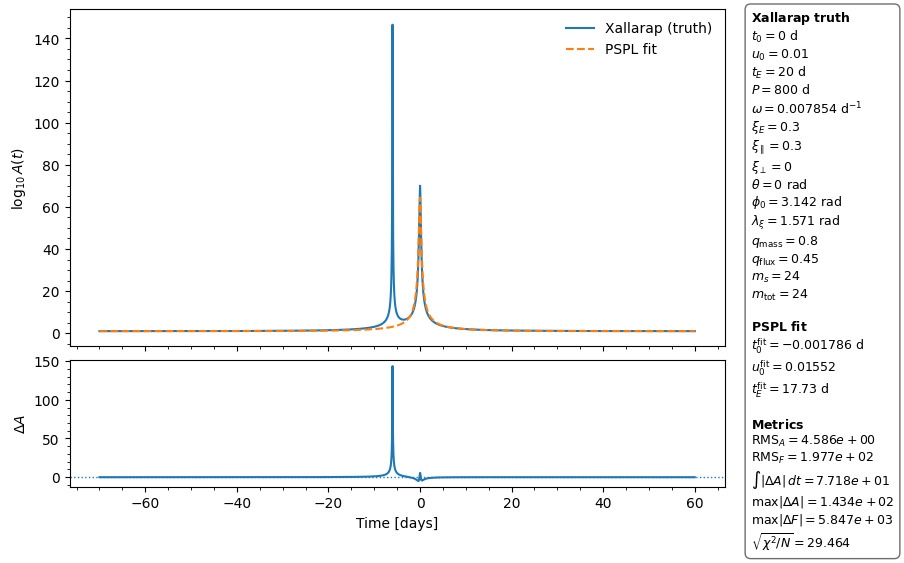

Best-fit (t0,u0,tE) = [-1.78605298e-03  1.55186652e-02  1.77253614e+01]
RMS_F = 197.7460700784322
RMS_A = 4.585598611933579


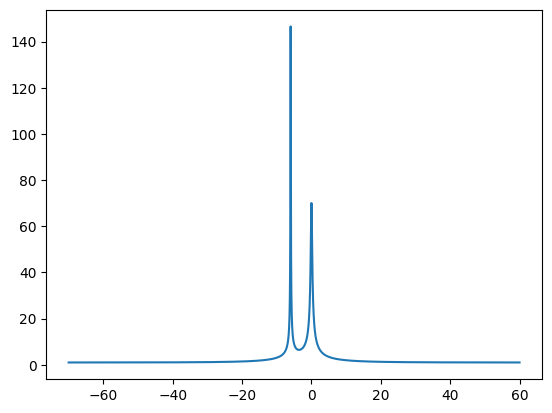

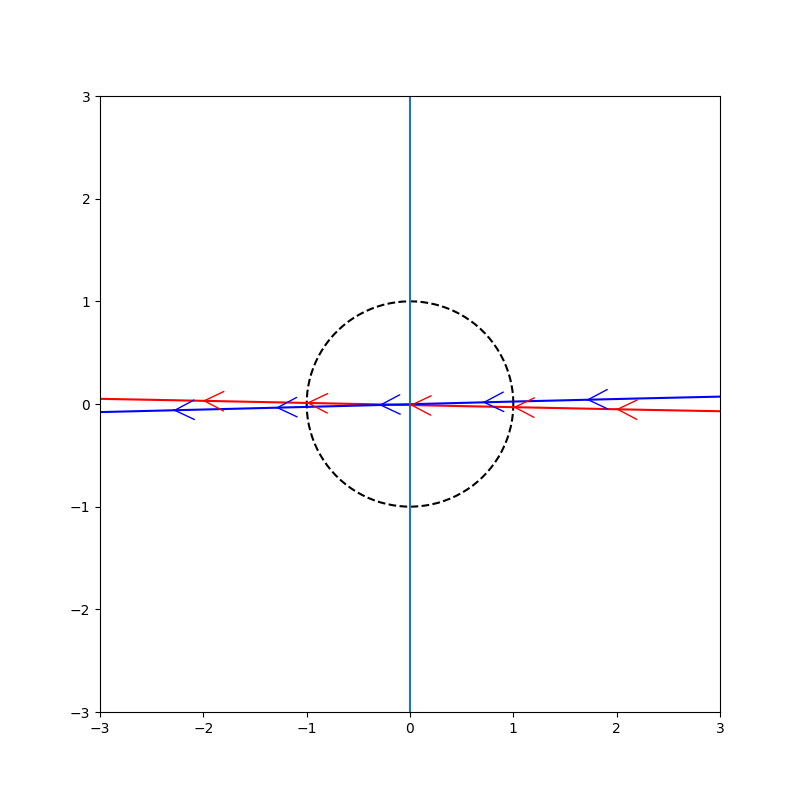

In [173]:

%matplotlib inline

plt.close("all")
out = single_period_fit_and_plot(
    P_days=800,
    t0_true=0.0, u0_true=0.01, tE_true=20.0,
    xiE=0.3,            
    theta=0, phi0=np.pi,
    lambda_xi=0.5*np.pi,
    q_mass=0.8, qflux=0.45,
    ms=24,
    mtotal=24,        
    override_xiE=None,   
    window_k=5.0,
    out_prefix="singleP_210d",
)

model_xal = out["model_xal"]
pyLIMA_parameters=out["pyLIMA_parameters"]
source1_trajectory_x, source1_trajectory_y,source2_trajectory_x, source2_trajectory_y, dseparation, dalpha = model_xal.sources_trajectory(model_xal.event.telescopes[0],
                             pyLIMA_parameters, data_type="photometry")

%matplotlib inline
plt.close("all")
telescope = model_xal.event.telescopes[0]
plt.plot(telescope.lightcurve["time"],model_xal.event.telescopes[0].lightcurve["flux"])
plt.show()
%matplotlib widget
plt.close("all")
plt.figure(figsize=(8,8))
plt.plot(np.cos(np.linspace(0,2*np.pi,200)),np.sin(np.linspace(0,2*np.pi,200)),color="k",linestyle="--")

colors=["red","blue"]
for i,trajectory in enumerate([[source1_trajectory_x, source1_trajectory_y],
                         [source2_trajectory_x, source2_trajectory_y] ]):
    # print(trajectory,i)
    color = colors[i]
    trajectory_x,trajectory_y=trajectory
    plt.plot(trajectory_x,trajectory_y,color=color)

    if trajectory_x is not None:
        for ind in [-2, -1, 0, 1, 2]:
            try:
                index = np.argmin(
                    np.abs(telescope.lightcurve['time'].value -
                           (pyLIMA_parameters['t0'] + ind * pyLIMA_parameters['tE'])))
                sign = np.sign(trajectory_x[index + 1] - trajectory_x[index])
                derivative = (trajectory_y[index - 1] - trajectory_y[index + 1]) / (
                        trajectory_x[index - 1] - trajectory_x[index + 1])
    
                plt.annotate('',
                                     xy=(trajectory_x[index], trajectory_y[index]),
                                     xytext=(trajectory_x[index] - (
                                             trajectory_x[index + 1] -
                                             trajectory_x[index]) * 0.001,
                                             trajectory_y[index] - (
                                                     trajectory_x[index + 1] -
                                                     trajectory_x[
                                                         index]) * 0.001 *
                                             derivative),
                                     arrowprops=dict(arrowstyle="->",
                                                     mutation_scale=35,
                                                     color=color))
            except IndexError:
                pass

plt.axvline(0)
plt.ylim(-3,3)
plt.xlim(-3,3)
plt.show()

In [156]:
# plt.close("all")
# plt.figure(figsize=(8,8))
# plt.plot(np.cos(np.linspace(0,2*np.pi,200)),np.sin(np.linspace(0,2*np.pi,200)))
# plt.plot(source1_trajectory_x, source1_trajectory_y)
# plt.plot(source2_trajectory_x, source2_trajectory_y)
# plt.ylim(-3,3)
# plt.xlim(-3,3)
# plt.show()

(<Figure size 750x750 with 1 Axes>, None)

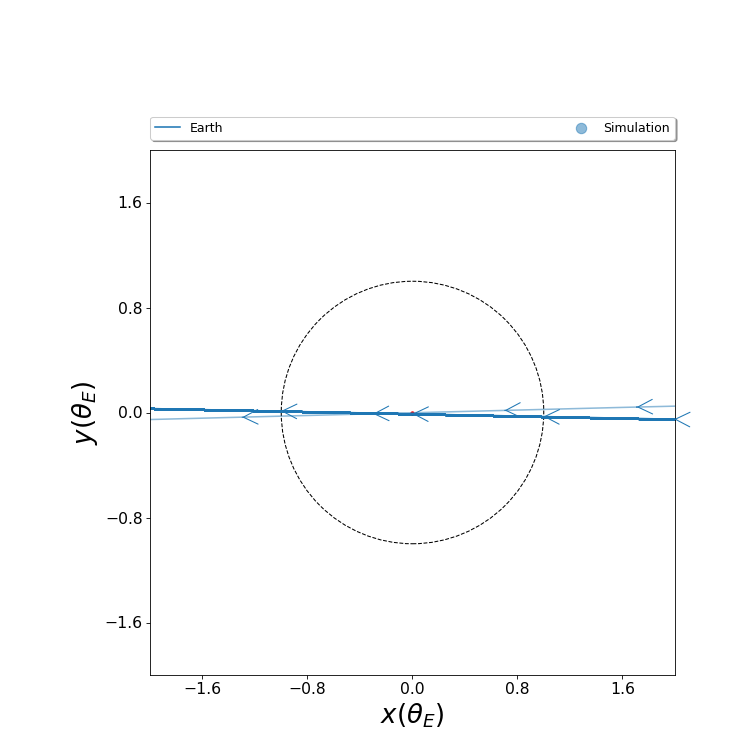

In [148]:
from pyLIMA.outputs import pyLIMA_plots
plt.close("all")
pyLIMA_plots.plot_geometry(model_xal, [0.0, 0.01, 20.0, np.float64(0.3), np.float64(0.0), 0.007853981633974483, 3.141592653589793, 1.5707963267948966, 0.8, 0.45, 27.92543841237335, 27.92543841237335, 0.0, 0.0])

In [142]:

# dseparation, dalpha

/tmp/ipykernel_346073/2991127965.py:559: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  INT_L1 = float(np.trapz(np.abs(resid_A[metric_mask]), t[metric_mask]))



Local PSPL fit peak 1
Detected t_peak = -69.39649396493965
Best t0, u0, tE = [-68.98712708   2.49614511  12.53107779]
RMS_A local = 0.00022416039459872874
max |Delta A| local = 0.000638944441204714

Local PSPL fit peak 2
Detected t_peak = 0.09860098600987044
Best t0, u0, tE = [0.09856665 0.52433332 0.51657736]
RMS_A local = 0.024587449894597994
max |Delta A| local = 0.20164383834567934


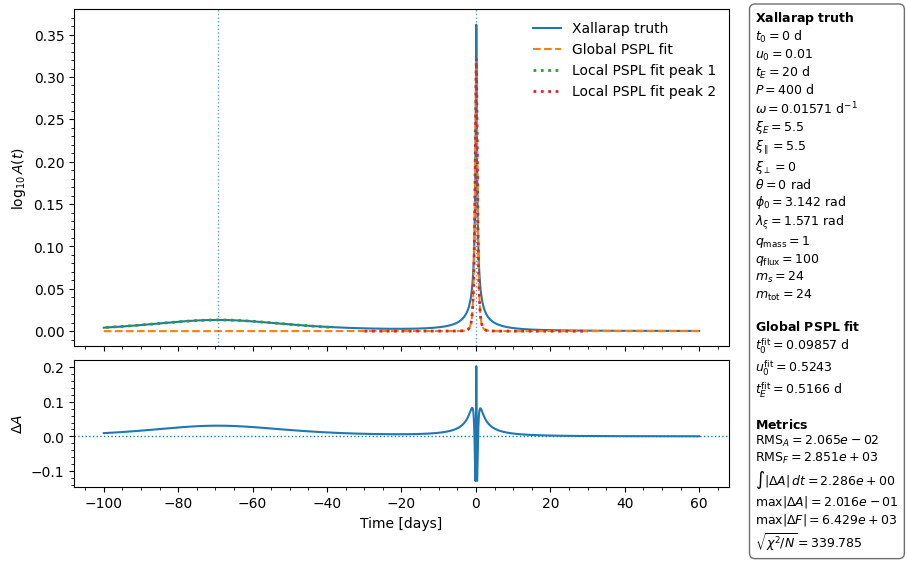

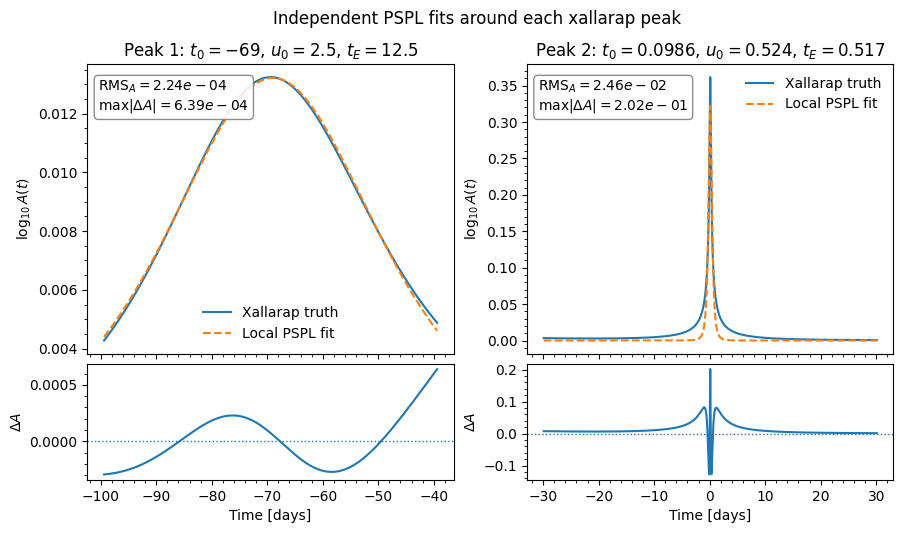


Global PSPL best-fit:
Best-fit [t0, u0, tE] = [0.09856647 0.52433337 0.51657747]
RMS_F = 2850.8647823817096
RMS_A = 0.02065189805648266
sqrt(chi2/N) = 339.7853086609379


/tmp/ipykernel_346073/2991127965.py:559: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  INT_L1 = float(np.trapz(np.abs(resid_A[metric_mask]), t[metric_mask]))



Local PSPL fit peak 1
Detected t_peak = -41.16261162611626
Best t0, u0, tE = [-40.96118987   0.77970501  16.03766246]
RMS_A local = 0.0039277237632131725
max |Delta A| local = 0.010246332049965279

Local PSPL fit peak 2
Detected t_peak = 0.06820068200681817
Best t0, u0, tE = [0.0672681  0.25428459 1.28929501]
RMS_A local = 0.10947197281173152
max |Delta A| local = 0.435695273044411


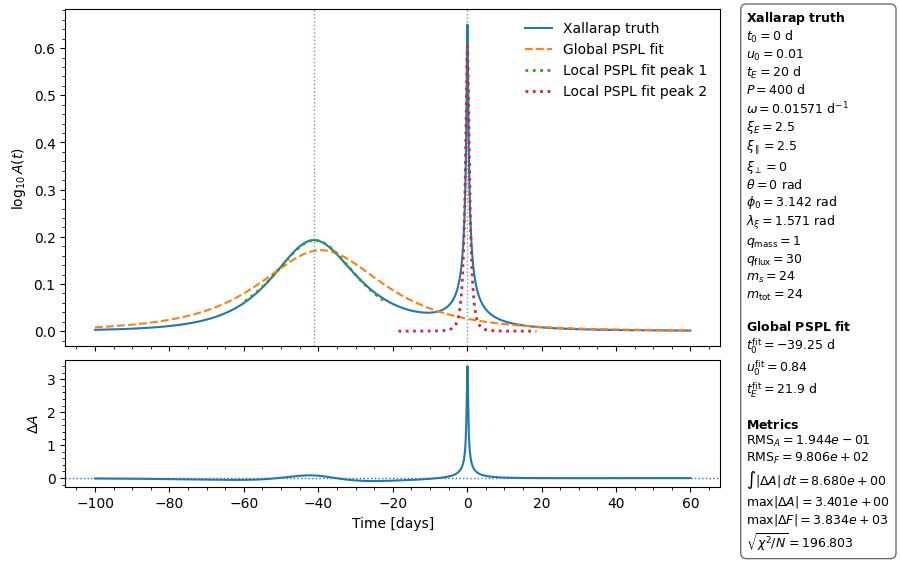

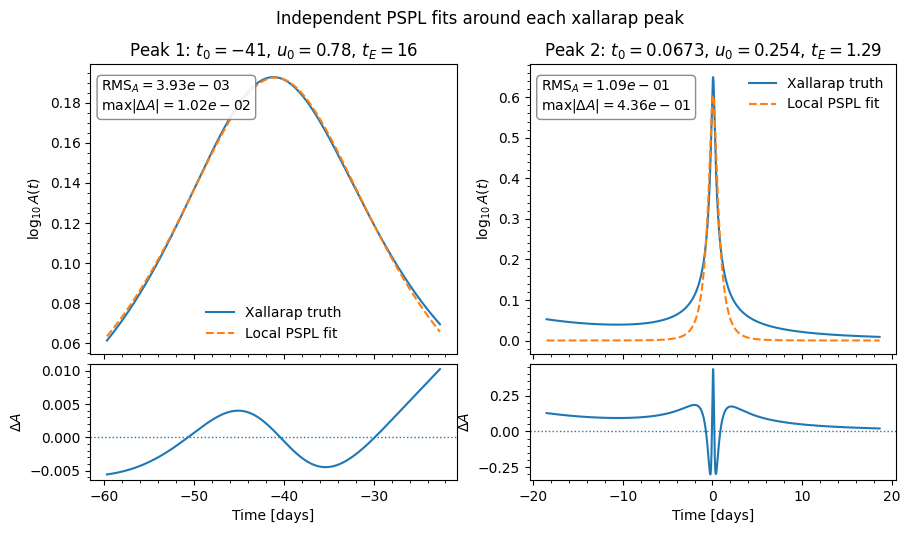


Global PSPL best-fit:
Best-fit [t0, u0, tE] = [-39.25097497   0.84002637  21.90317703]
RMS_F = 980.5808732220643
RMS_A = 0.1944362093772907
sqrt(chi2/N) = 196.8030894513669


/tmp/ipykernel_346073/2991127965.py:559: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  INT_L1 = float(np.trapz(np.abs(resid_A[metric_mask]), t[metric_mask]))



Local PSPL fit peak 1
Detected t_peak = -69.39649396493965
Best t0, u0, tE = [-68.98712708   2.49614511  12.53107779]
RMS_A local = 0.00022416039459872874
max |Delta A| local = 0.000638944441204714

Local PSPL fit peak 2
Detected t_peak = 0.09860098600987044
Best t0, u0, tE = [0.09856665 0.52433332 0.51657736]
RMS_A local = 0.024587449894597994
max |Delta A| local = 0.20164383834567934


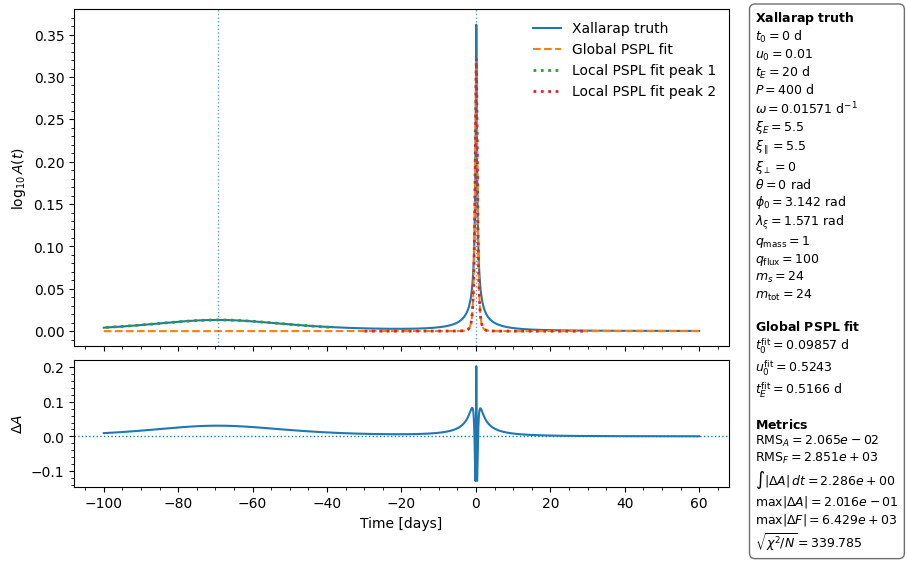

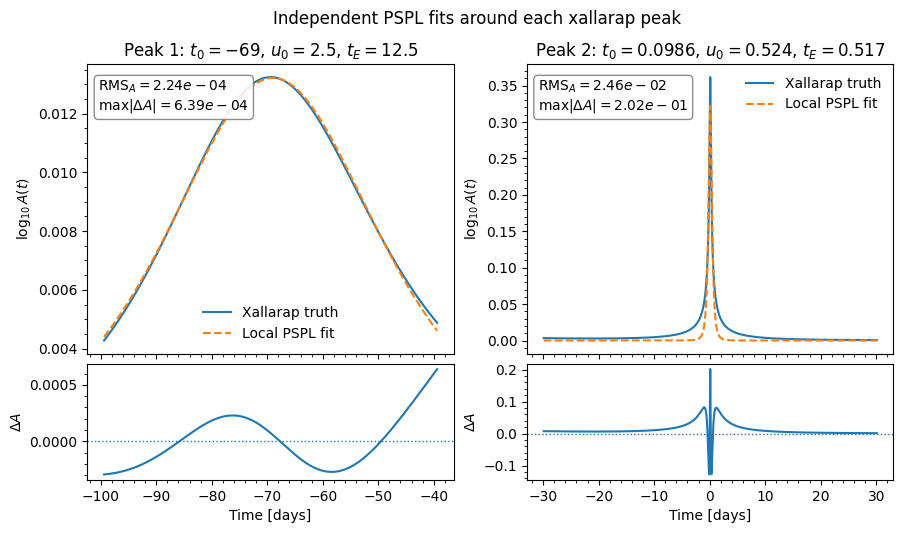


Global PSPL best-fit:
Best-fit [t0, u0, tE] = [0.09856647 0.52433337 0.51657747]
RMS_F = 2850.8647823817096
RMS_A = 0.02065189805648266
sqrt(chi2/N) = 339.7853086609379


/tmp/ipykernel_346073/2991127965.py:559: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  INT_L1 = float(np.trapz(np.abs(resid_A[metric_mask]), t[metric_mask]))


RuntimeError: Se encontraron solo 1 picos. Probá bajar prominence_frac o min_separation_days, o cambiar la ventana de búsqueda.

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import scipy.optimize as so
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model
from pyLIMA.simulations import simulator


# ============================================================
# Photometric noise model
# ============================================================

mag_grid = np.array([
    12.0, 12.5, 13.0, 13.5, 14.0, 14.5,
    15.0, 15.5, 16.0, 16.5, 17.0, 17.5,
    18.0, 18.5, 19.0, 19.5, 20.0, 20.5,
    21.0, 21.5, 22.0, 22.5, 23.0, 23.5,
    24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0
])

sigma_W149_grid = np.array([
    0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
    0.0010475, 0.0011229, 0.0012038, 0.0013207,
    0.0015178, 0.0017852, 0.002139, 0.0025867,
    0.0032066, 0.0039261, 0.0050352, 0.0063881,
    0.0082817, 0.01087, 0.014603, 0.019616,
    0.027602, 0.039749, 0.058585, 0.088371,
    0.13351, 0.20964, 0.32165, 0.51373, 1.0
])

sigma_interp_log = interp1d(
    mag_grid,
    np.log10(sigma_W149_grid),
    kind="linear",
    bounds_error=True
)

ZP = 27.615


def sigma_W149_func(W149):
    W149 = np.asarray(W149)
    log_sigma = sigma_interp_log(W149)
    return 10.0**log_sigma


def mag_to_flux(mag, zp=ZP):
    return 10.0**(-0.4 * (mag - zp))


def flux_to_mag(flux, zp=ZP):
    flux = np.asarray(flux)
    return zp - 2.5 * np.log10(np.abs(flux))


def sigma_flux_from_flux(flux, zp=ZP):
    flux = np.asarray(flux)
    mag = flux_to_mag(flux, zp=zp)
    sigma_mag = sigma_W149_func(mag)
    return (np.log(10.0) / 2.5) * flux * sigma_mag


def mag_from_flux(zp, Flux):
    return zp - 2.5 * np.log10(np.abs(Flux))


# ============================================================
# Basic pyLIMA helpers
# ============================================================

def build_sim_event(t, mag0=19.0, emag=1e-9, filt="G"):
    ev = event.Event()
    ev.name = "Simulated"
    ev.ra = 170
    ev.dec = -70

    lc = np.c_[t, np.full_like(t, mag0), np.full_like(t, emag)]

    tel = telescopes.Telescope(
        name="Simulation",
        camera_filter=filt,
        lightcurve=lc.astype(float),
        lightcurve_names=["time", "mag", "err_mag"],
        lightcurve_units=["JD", "mag", "mag"],
        location="Earth",
    )

    ev.telescopes.append(tel)
    return ev


def build_event_with_flux(t, flux_data, mag0=19.0, emag=1e-9, filt="G"):
    """
    Construye un evento pyLIMA y fuerza la columna flux.
    Sirve para ajustar directamente en magnificación.
    """
    ev = build_sim_event(t, mag0=mag0, emag=emag, filt=filt)
    ev.telescopes[0].lightcurve["flux"] = np.asarray(flux_data, dtype=float)
    return ev


def chi2_theoretical_local(
    fit_params,
    your_model,
    use_magnification=False,
    fs_fixed=1.0,
    ftotal_fixed=1.0,
):
    """
    SSE sin pesos: compara data vs modelo.
    fit_params = [t0, u0, tE]

    Si use_magnification=True:
        compara telescope.lightcurve['flux'] con A_model.

    Si use_magnification=False:
        compara telescope.lightcurve['flux'] con flujo de pyLIMA.
    """

    fit_params = np.asarray(fit_params, dtype=float)

    if not np.all(np.isfinite(fit_params)):
        return 1e100

    t0, u0, tE = fit_params

    if u0 <= 0 or tE <= 0:
        return 1e100

    full_params = np.concatenate([fit_params, [fs_fixed, ftotal_fixed]])

    try:
        py_params = your_model.compute_pyLIMA_parameters(full_params)
    except Exception:
        return 1e100

    sse = 0.0

    for telescope in your_model.event.telescopes:
        if telescope.lightcurve is None:
            continue

        data = np.asarray(telescope.lightcurve["flux"].value, dtype=float)

        try:
            if use_magnification:
                model = your_model.model_magnification(telescope, py_params)
            else:
                model = your_model.compute_the_microlensing_model(
                    telescope,
                    py_params
                )["photometry"]
        except Exception:
            return 1e100

        model = np.asarray(model, dtype=float)

        if len(model) != len(data):
            return 1e100

        if not np.all(np.isfinite(model)):
            return 1e100

        sse += np.sum((data - model)**2)

    return float(sse)


def invert_pspl_A_to_u(A):
    """
    Inversa aproximada exacta de A(u) para PSPL.
    Para A <= 1 devuelve un valor grande.
    """
    A = float(A)

    if A <= 1.0:
        return 5.0

    return np.sqrt(2.0 * (A / np.sqrt(A**2 - 1.0) - 1.0))


# ============================================================
# Peak detection and local PSPL fits
# ============================================================

def find_two_main_peaks(
    t,
    A,
    search_mask=None,
    min_separation_days=5.0,
    prominence_frac=0.02,
):
    """
    Busca los dos máximos principales dentro de search_mask.
    Devuelve índices globales en los arrays originales.
    """

    t = np.asarray(t)
    A = np.asarray(A)

    if search_mask is None:
        search_mask = np.ones_like(t, dtype=bool)

    idx_search = np.where(search_mask)[0]

    if len(idx_search) < 10:
        raise RuntimeError("La máscara de búsqueda tiene muy pocos puntos.")

    t_s = t[idx_search]
    A_s = A[idx_search]

    dt = np.median(np.diff(t_s))
    distance = max(1, int(min_separation_days / dt))

    A_range = np.nanmax(A_s) - np.nanmin(A_s)
    prominence = prominence_frac * A_range

    peaks_s, props = find_peaks(
        A_s,
        distance=distance,
        prominence=prominence,
    )

    if len(peaks_s) < 2:
        # Segundo intento más permisivo
        peaks_s, props = find_peaks(
            A_s,
            distance=distance,
            prominence=0.2 * prominence,
        )

    if len(peaks_s) < 2:
        raise RuntimeError(
            f"Se encontraron solo {len(peaks_s)} picos. "
            "Probá bajar prominence_frac o min_separation_days, "
            "o cambiar la ventana de búsqueda."
        )

    # Ordenar por altura
    order_height = np.argsort(A_s[peaks_s])[::-1]
    peaks_s = peaks_s[order_height]

    # Tomar los dos más altos
    two_s = peaks_s[:2]

    # Pasar a índices globales
    two_global = idx_search[two_s]

    # Ordenar temporalmente
    two_global = two_global[np.argsort(t[two_global])]

    return two_global


def fit_pspl_local_peak(
    t,
    A_data,
    peak_index,
    peak_window_days=20.0,
    u0_guess=None,
    tE_guess=20.0,
):
    """
    Ajusta un PSPL local a una ventana alrededor de un pico.
    El ajuste se hace directamente en magnificación:
        A_data vs A_PSPL.
    """

    t = np.asarray(t)
    A_data = np.asarray(A_data)

    t_peak = float(t[peak_index])

    mask_peak = np.abs(t - t_peak) <= peak_window_days

    t_local = t[mask_peak]
    A_local = A_data[mask_peak]

    if len(t_local) < 30:
        raise RuntimeError(
            "Muy pocos puntos en la ventana local del pico. "
            "Aumentá peak_window_days."
        )

    Amax = float(np.nanmax(A_local))

    if u0_guess is None:
        u0_guess = invert_pspl_A_to_u(Amax)
        u0_guess = np.clip(u0_guess, 1e-4, 3.0)

    ev_peak = build_event_with_flux(
        t_local,
        A_local,
        mag0=19.0,
        emag=1e-9,
        filt="G",
    )

    model_peak = PSPL_model.PSPLmodel(
        ev_peak,
        parallax=["None", 0.0],
        double_source=["None", 0.0],
    )

    model_peak.define_model_parameters()

    x0 = np.array([t_peak, u0_guess, tE_guess], dtype=float)

    bounds = [
        (t_peak - peak_window_days, t_peak + peak_window_days),
        (1e-4, 10.0),
        (0.05, 10.0 * peak_window_days),
    ]

    res = so.minimize(
        chi2_theoretical_local,
        x0=x0,
        args=(model_peak, True, 1.0, 1.0),
        method="Powell",
        bounds=bounds,
        options=dict(
            maxiter=100000,
            xtol=1e-10,
            ftol=1e-10,
        ),
    )

    if not res.success:
        print("Warning: local PSPL fit failed:", res.message)

    best = np.asarray(res.x, dtype=float)

    best_full = np.concatenate([best, [1.0, 1.0]])
    py_best = model_peak.compute_pyLIMA_parameters(best_full)

    A_fit_local = model_peak.model_magnification(
        ev_peak.telescopes[0],
        py_best,
    )

    resid_local = A_local - A_fit_local

    rms_local = float(np.sqrt(np.mean(resid_local**2)))
    max_abs_local = float(np.max(np.abs(resid_local)))

    return dict(
        t_peak=t_peak,
        peak_index=peak_index,
        peak_window_days=peak_window_days,
        mask_peak=mask_peak,
        t_local=t_local,
        A_local=A_local,
        A_fit_local=A_fit_local,
        resid_local=resid_local,
        best=best,
        rms=rms_local,
        max_abs=max_abs_local,
        result=res,
    )


# ============================================================
# Main function
# ============================================================

def single_period_fit_and_plot(
    P_days: float,
    # PSPL base
    t0_true: float = 50.0,
    u0_true: float = 0.1,
    tE_true: float = 173.0,
    # xallarap geometry
    xiE: float = 0.1,
    theta: float = 0.0,
    phi0: float = 0.0,
    lambda_xi: float = 0.5 * np.pi,
    q_mass: float = 1.0,
    qflux: float = 0.0,
    # photometry
    ms: float = 24.0,
    mtotal: float = 24.0,
    # isolate knobs
    override_xiE: float | None = None,
    window_k: float | None = 5.0,
    peak_search_k: float | None = 5.0,
    local_window_days: float | None = None,
    n_points: int = 100000,
    out_prefix: str = "singleP",
):
    """
    Genera una curva Xallarap truth para un solo P,
    ajusta un PSPL global y luego ajusta PSPL locales en cada pico.

    local_window_days:
        None -> usa una ventana automática basada en la separación entre picos.
        float -> usa ese ancho fijo alrededor de cada pico.
    """

    # ------------------------------------------------------------
    # Time grid
    # ------------------------------------------------------------
    t_min = t0_true - 5.0 * tE_true
    t_max = t0_true + 3.0 * tE_true

    t = np.linspace(t_min, t_max, int(n_points))

    omega = 2.0 * np.pi / float(P_days)

    if override_xiE is not None:
        xiE_use = float(override_xiE)
    else:
        xiE_use = float(xiE)

    xi_para = xiE_use * np.cos(theta)
    xi_perp = xiE_use * np.sin(theta)

    # ------------------------------------------------------------
    # Xallarap truth
    # ------------------------------------------------------------
    ev = build_sim_event(t, mag0=19.0, emag=1e-9, filt="G")

    model_xal = PSPL_model.PSPLmodel(
        ev,
        parallax=["None", 0.0],
        double_source=["Circular", t0_true],
    )

    model_xal.define_model_parameters()

    fs = mag_to_flux(ms, zp=ZP)
    ftotal = mag_to_flux(mtotal, zp=ZP)

    params_xal = [
        t0_true,
        u0_true,
        tE_true,
        xi_para,
        xi_perp,
        omega,
        phi0,
        lambda_xi,
        q_mass,
        qflux,
        fs,
        ftotal,
    ]

    py_params_xal = model_xal.compute_pyLIMA_parameters(params_xal)

    simulator.simulate_lightcurve(model_xal, py_params_xal)

    A_truth = model_xal.model_magnification(
        ev.telescopes[0],
        py_params_xal,
    ) / (1.0 + qflux)

    F_truth = model_xal.compute_the_microlensing_model(
        ev.telescopes[0],
        py_params_xal,
    )["photometry"]

    ev.telescopes[0].lightcurve["flux"] = A_truth
    ev.telescopes[0].lightcurve["mag"] = mag_from_flux(ZP, F_truth)

    # ------------------------------------------------------------
    # Global PSPL fit
    # ------------------------------------------------------------
    model_pspl = PSPL_model.PSPLmodel(
        ev,
        parallax=["None", 0.0],
        double_source=["None", 0.0],
    )

    model_pspl.define_model_parameters()

    x0 = np.array([t0_true, max(u0_true, 1e-4), tE_true], dtype=float)

    global_bounds = [
        (t_min, t_max),
        (1e-4, 10.0),
        (0.05, 10.0 * tE_true),
    ]

    res = so.minimize(
        chi2_theoretical_local,
        x0=x0,
        args=(model_pspl, True, fs, ftotal),
        method="Powell",
        bounds=global_bounds,
        options=dict(
            maxiter=200000,
            xtol=1e-10,
            ftol=1e-10,
        ),
    )

    if not res.success:
        print("Warning: global PSPL fit failed:", res.message)

    best = np.asarray(res.x, dtype=float)

    best_full = np.concatenate([best, [fs, ftotal]])

    t0_ml, u0_ml, tE_ml = best_full[0], best_full[1], best_full[2]

    py_best = model_pspl.compute_pyLIMA_parameters(best_full)

    F_fit = model_pspl.compute_the_microlensing_model(
        ev.telescopes[0],
        py_best,
    )["photometry"]

    A_fit = model_pspl.model_magnification(
        ev.telescopes[0],
        py_best,
    )

    resid_F = F_truth - F_fit
    resid_A = A_truth - A_fit

    # ------------------------------------------------------------
    # Masks
    # ------------------------------------------------------------
    if window_k is not None:
        time_mask = np.abs(t - t0_true) <= float(window_k) * tE_true
    else:
        time_mask = np.ones_like(t, dtype=bool)

    mag_truth = flux_to_mag(F_truth)
    mag_fit = flux_to_mag(F_fit)

    mag_mask = (
        (mag_truth >= 12.0) & (mag_truth <= 27.0)
        & (mag_fit >= 12.0) & (mag_fit <= 27.0)
    )

    metric_mask = time_mask & mag_mask

    if np.sum(metric_mask) < 10:
        raise ValueError(
            "Muy pocos puntos válidos después de aplicar las máscaras."
        )

    rms_F = float(np.sqrt(np.mean(resid_F[metric_mask]**2)))
    rms_A = float(np.sqrt(np.mean(resid_A[metric_mask]**2)))

    F_truth_m = F_truth[metric_mask]
    F_fit_m = F_fit[metric_mask]

    err_truth = sigma_flux_from_flux(F_truth_m)
    residuals = F_truth_m - F_fit_m

    q_A = np.sum((residuals / err_truth)**2) / len(residuals)

    INT_L1 = float(np.trapz(np.abs(resid_A[metric_mask]), t[metric_mask]))
    max_abs_resid_F = float(np.max(np.abs(resid_F[metric_mask])))
    max_abs_resid_A = float(np.max(np.abs(resid_A[metric_mask])))

    # ------------------------------------------------------------
    # Find peaks and local PSPL fits
    # ------------------------------------------------------------
    if peak_search_k is not None:
        peak_search_mask = np.abs(t - t0_true) <= float(peak_search_k) * tE_true
    else:
        peak_search_mask = time_mask.copy()

    peak_indices = find_two_main_peaks(
        t,
        A_truth,
        search_mask=peak_search_mask,
        min_separation_days=0.3 * tE_true,
        prominence_frac=0.015,
    )

    peak_times = t[peak_indices]
    peak_separation = float(np.abs(peak_times[1] - peak_times[0]))

    local_fits = []

    for j, peak_idx in enumerate(peak_indices):

        if local_window_days is None:
            this_window = min(
                1.5 * tE_true,
                0.45 * peak_separation,
            )
            this_window = max(this_window, 3.0)
        else:
            this_window = float(local_window_days)

        fit_j = fit_pspl_local_peak(
            t=t,
            A_data=A_truth,
            peak_index=peak_idx,
            peak_window_days=this_window,
            u0_guess=None,
            tE_guess=0.5 * tE_true,
        )

        local_fits.append(fit_j)

        print(f"\nLocal PSPL fit peak {j+1}")
        print("Detected t_peak =", fit_j["t_peak"])
        print("Best t0, u0, tE =", fit_j["best"])
        print("RMS_A local =", fit_j["rms"])
        print("max |Delta A| local =", fit_j["max_abs"])

    # ============================================================
    # Global plot
    # ============================================================

    fig = plt.figure(figsize=(11.8, 6.2))

    gs = fig.add_gridspec(
        2,
        1,
        height_ratios=[3.2, 1.2],
        hspace=0.06,
    )

    ax = fig.add_subplot(gs[0, 0])
    axr = fig.add_subplot(gs[1, 0], sharex=ax)

    ax.plot(
        t[time_mask],
        np.log10(A_truth[time_mask]),
        label="Xallarap truth",
    )

    ax.plot(
        t[time_mask],
        np.log10(A_fit[time_mask]),
        "--",
        label="Global PSPL fit",
    )

    for j, fit_j in enumerate(local_fits):
        ax.plot(
            fit_j["t_local"],
            np.log10(fit_j["A_fit_local"]),
            ":",
            linewidth=2.0,
            label=rf"Local PSPL fit peak {j+1}",
        )

        ax.axvline(
            fit_j["t_peak"],
            linestyle=":",
            linewidth=1.0,
            alpha=0.7,
        )

    ax.set_ylabel(r"$\log_{10} A(t)$")
    ax.legend(frameon=False, loc="best")

    param_text = (
        r"$\bf{Xallarap\ truth}$" + "\n"
        rf"$t_0 = {t0_true:.4g}\ \mathrm{{d}}$" + "\n"
        rf"$u_0 = {u0_true:.4g}$" + "\n"
        rf"$t_E = {tE_true:.4g}\ \mathrm{{d}}$" + "\n"
        rf"$P = {P_days:.4g}\ \mathrm{{d}}$" + "\n"
        rf"$\omega = {omega:.4g}\ \mathrm{{d}}^{{-1}}$" + "\n"
        rf"$\xi_E = {xiE_use:.4g}$" + "\n"
        rf"$\xi_\parallel = {xi_para:.4g}$" + "\n"
        rf"$\xi_\perp = {xi_perp:.4g}$" + "\n"
        rf"$\theta = {theta:.4g}\ \mathrm{{rad}}$" + "\n"
        rf"$\phi_0 = {phi0:.4g}\ \mathrm{{rad}}$" + "\n"
        rf"$\lambda_\xi = {lambda_xi:.4g}\ \mathrm{{rad}}$" + "\n"
        rf"$q_\mathrm{{mass}} = {q_mass:.4g}$" + "\n"
        rf"$q_\mathrm{{flux}} = {qflux:.4g}$" + "\n"
        rf"$m_s = {ms:.4g}$" + "\n"
        rf"$m_\mathrm{{tot}} = {mtotal:.4g}$" + "\n"
        "\n"
        r"$\bf{Global\ PSPL\ fit}$" + "\n"
        rf"$t_0^\mathrm{{fit}} = {t0_ml:.4g}\ \mathrm{{d}}$" + "\n"
        rf"$u_0^\mathrm{{fit}} = {u0_ml:.4g}$" + "\n"
        rf"$t_E^\mathrm{{fit}} = {tE_ml:.4g}\ \mathrm{{d}}$" + "\n"
        "\n"
        r"$\bf{Metrics}$" + "\n"
        rf"$\mathrm{{RMS}}_A = {rms_A:.3e}$" + "\n"
        rf"$\mathrm{{RMS}}_F = {rms_F:.3e}$" + "\n"
        rf"$\int |\Delta A|\,dt = {INT_L1:.3e}$" + "\n"
        rf"$\max|\Delta A| = {max_abs_resid_A:.3e}$" + "\n"
        rf"$\max|\Delta F| = {max_abs_resid_F:.3e}$" + "\n"
        rf"$\sqrt{{\chi^2/N}} = {np.sqrt(q_A):.3f}$"
    )

    ax.annotate(
        param_text,
        xy=(1.04, 1.00),
        xycoords="axes fraction",
        va="top",
        ha="left",
        fontsize=9,
        annotation_clip=False,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.4",
            alpha=0.95,
        ),
    )

    axr.plot(
        t[time_mask],
        resid_A[time_mask],
    )

    axr.axhline(
        0.0,
        linestyle=":",
        linewidth=1.0,
    )

    axr.set_xlabel("Time [days]")
    axr.set_ylabel(r"$\Delta A$")

    ax.yaxis.set_minor_locator(AutoMinorLocator())
    axr.yaxis.set_minor_locator(AutoMinorLocator())
    axr.xaxis.set_minor_locator(AutoMinorLocator())

    plt.setp(ax.get_xticklabels(), visible=False)

    fig.subplots_adjust(right=0.68)

    fig.savefig(f"{out_prefix}_global_and_local_PSPL.png", bbox_inches="tight")
    fig.savefig(f"{out_prefix}_global_and_local_PSPL.pdf", bbox_inches="tight")

    plt.show()

    # ============================================================
    # Local peak plots
    # ============================================================

    fig2, axes = plt.subplots(
        2,
        len(local_fits),
        figsize=(5.2 * len(local_fits), 5.4),
        sharex="col",
        gridspec_kw=dict(
            height_ratios=[3.0, 1.2],
            hspace=0.05,
        ),
    )

    if len(local_fits) == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for j, fit_j in enumerate(local_fits):
        axp = axes[0, j]
        axpr = axes[1, j]

        axp.plot(
            fit_j["t_local"],
            np.log10(fit_j["A_local"]),
            label="Xallarap truth",
        )

        axp.plot(
            fit_j["t_local"],
            np.log10(fit_j["A_fit_local"]),
            "--",
            label="Local PSPL fit",
        )

        axpr.plot(
            fit_j["t_local"],
            fit_j["resid_local"],
        )

        axpr.axhline(
            0.0,
            linestyle=":",
            linewidth=1.0,
        )

        t0_j, u0_j, tE_j = fit_j["best"]

        axp.set_title(
            rf"Peak {j+1}: "
            rf"$t_0={t0_j:.3g}$, "
            rf"$u_0={u0_j:.3g}$, "
            rf"$t_E={tE_j:.3g}$"
        )

        axp.text(
            0.03,
            0.95,
            rf"$\mathrm{{RMS}}_A={fit_j['rms']:.2e}$" + "\n"
            rf"$\max|\Delta A|={fit_j['max_abs']:.2e}$",
            transform=axp.transAxes,
            va="top",
            ha="left",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="0.5",
                alpha=0.9,
            ),
        )

        axp.legend(frameon=False)

        axp.set_ylabel(r"$\log_{10} A(t)$")
        axpr.set_xlabel("Time [days]")
        axpr.set_ylabel(r"$\Delta A$")

        axp.yaxis.set_minor_locator(AutoMinorLocator())
        axpr.yaxis.set_minor_locator(AutoMinorLocator())
        axpr.xaxis.set_minor_locator(AutoMinorLocator())

    fig2.suptitle("Independent PSPL fits around each xallarap peak")

    fig2.savefig(f"{out_prefix}_local_peak_fits.png", bbox_inches="tight")
    fig2.savefig(f"{out_prefix}_local_peak_fits.pdf", bbox_inches="tight")

    plt.show()

    print("\nGlobal PSPL best-fit:")
    print("Best-fit [t0, u0, tE] =", best)
    print("RMS_F =", rms_F)
    print("RMS_A =", rms_A)
    print("sqrt(chi2/N) =", np.sqrt(q_A))

    return dict(
        t=t,
        time_mask=time_mask,
        metric_mask=metric_mask,
        best=best,
        F_truth=F_truth,
        F_fit=F_fit,
        A_truth=A_truth,
        A_fit=A_fit,
        RMS_F=rms_F,
        RMS_A=rms_A,
        q_A=q_A,
        local_fits=local_fits,
        peak_indices=peak_indices,
        peak_times=peak_times,
        peak_separation=peak_separation,
        params_xal=params_xal,
    )


# ============================================================
# Example: one case
# ============================================================

# En notebook:
# %matplotlib widget
# o también:
# %matplotlib inline

# plt.close("all")

out = single_period_fit_and_plot(
    P_days=400,
    t0_true=0.0,
    u0_true=0.01,
    tE_true=20.0,
    xiE=5.5,
    theta=0.0,
    phi0=np.pi,
    lambda_xi=0.5 * np.pi,
    q_mass=1.0,
    qflux=100.0,
    ms=24,
    mtotal=24,
    override_xiE=None,
    window_k=5.0,
    peak_search_k=5.0,
    local_window_days=None,
    n_points=100000,
    out_prefix="xallarap_two_peak_example",
)


# ============================================================
# Several cases
# ============================================================

cases = [
    dict(
        name="case_00",
        P_days=400,
        xiE=2.5,
        qflux=30.0,
        phi0=np.pi,
    ),
    dict(
        name="case_01",
        P_days=400,
        xiE=5.5,
        qflux=100.0,
        phi0=np.pi,
    ),
    dict(
        name="case_02",
        P_days=250,
        xiE=3.0,
        qflux=30.0,
        phi0=0.5 * np.pi,
    ),
    dict(
        name="case_03",
        P_days=600,
        xiE=6.0,
        qflux=100.0,
        phi0=1.2 * np.pi,
    ),
]

outs = []
%matplotlib inline
for case in cases:
    plt.close("all")

    out_case = single_period_fit_and_plot(
        P_days=case["P_days"],
        t0_true=0.0,
        u0_true=0.01,
        tE_true=20.0,
        xiE=case["xiE"],
        theta=0.0,
        phi0=case["phi0"],
        lambda_xi=0.5 * np.pi,
        q_mass=1.0,
        qflux=case["qflux"],
        ms=24,
        mtotal=24,
        override_xiE=None,
        window_k=5.0,
        peak_search_k=5.0,
        local_window_days=None,
        n_points=100000,
        out_prefix=f"xallarap_two_peak_{case['name']}",
    )

    outs.append(out_case)

mtotal_new = 23.59657999441256
P/tE       = 30.0
xiE/u0     = 13.333333333333334
K          = 0.16755160819145562


/tmp/ipykernel_346073/2991127965.py:559: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  INT_L1 = float(np.trapz(np.abs(resid_A[metric_mask]), t[metric_mask]))



Local PSPL fit peak 1
Detected t_peak = -23.780337803378046
Best t0, u0, tE = [-23.77609265   0.04364443  11.45745424]
RMS_A local = 0.6117104625480604
max |Delta A| local = 1.175648545850031

Local PSPL fit peak 2
Detected t_peak = 0.1287012870128592
Best t0, u0, tE = [ 0.09929455  0.08476199 23.38435133]
RMS_A local = 0.16175244116231538
max |Delta A| local = 0.4220273875868905


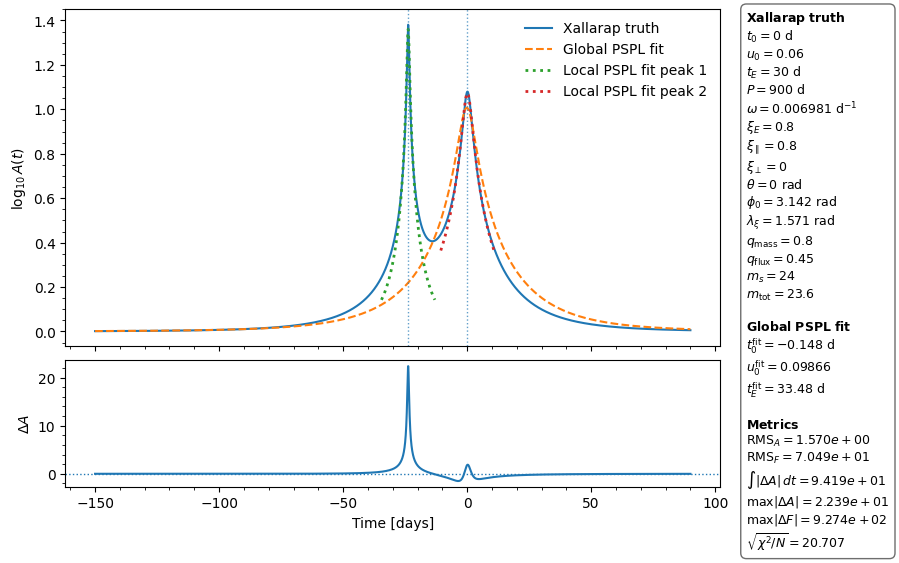

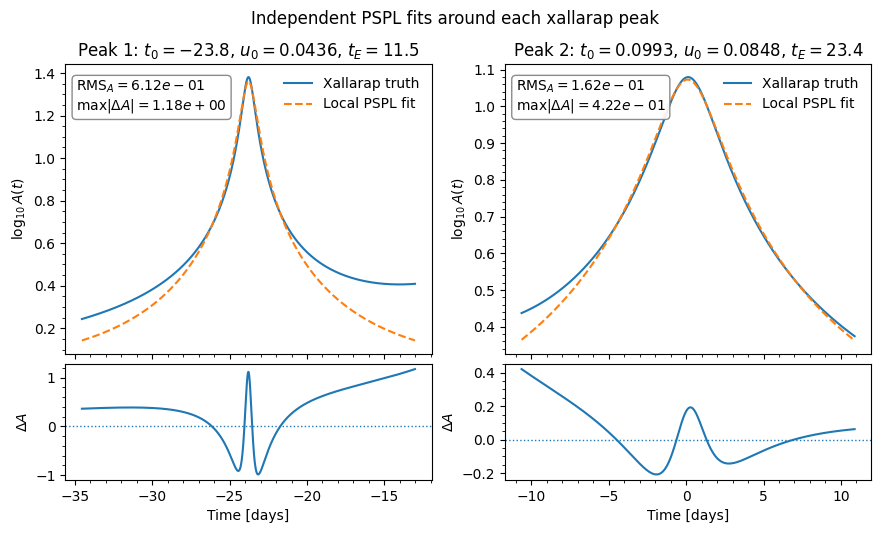


Global PSPL best-fit:
Best-fit [t0, u0, tE] = [-0.14804814  0.0986586  33.48474175]
RMS_F = 70.48550910386837
RMS_A = 1.5699910800982197
sqrt(chi2/N) = 20.706743808388385

Summary: new_case_two_peak_test
P/tE              = 30.000
xiE/u0            = 13.333
K = 2 pi tE xiE/P = 0.168
Number of peaks   = 2
All peak times    = [-23.7803378    0.12870129]
Two main peaks    = [-23.7803378    0.12870129]
Delta tau         = 0.797
RMS_A global      = 1.570e+00
RMS_A peak 1      = 6.117e-01
RMS_A peak 2      = 1.618e-01
two-PSPL score    = 4.060
two_pspl_like     = False


In [50]:
import pandas as pd


def mtotal_from_ms_qflux(ms, qflux, zp=ZP):
    """
    Si ms es la magnitud de la fuente principal y qflux = F2/F1,
    devuelve la magnitud total sin blend:
        Ftot = F1 * (1 + qflux)
    """
    fs = mag_to_flux(ms, zp=zp)
    ftotal = fs * (1.0 + qflux)
    return flux_to_mag(ftotal, zp=zp)


def count_detectable_peaks(
    t,
    A,
    tE,
    search_mask=None,
    min_separation_factor=0.3,
    prominence_frac=0.02,
):
    """
    Cuenta todos los picos detectables, no solo los dos principales.
    Esto permite verificar si hay exactamente dos picos.
    """

    if search_mask is None:
        search_mask = np.ones_like(t, dtype=bool)

    idx = np.where(search_mask)[0]

    t_s = t[idx]
    A_s = A[idx]

    dt = np.median(np.diff(t_s))

    distance = max(1, int(min_separation_factor * tE / dt))
    prominence = prominence_frac * (np.nanmax(A_s) - np.nanmin(A_s))

    peaks_s, props = find_peaks(
        A_s,
        distance=distance,
        prominence=prominence,
    )

    peaks_global = idx[peaks_s]

    return peaks_global, props


def summarize_case(out, P_days, tE_true, u0_true, xiE, label="case"):
    """
    Resume si el caso generado tiene:
    - exactamente dos picos detectables;
    - separación temporal razonable;
    - buen ajuste PSPL local en cada pico;
    - mal ajuste PSPL global.
    """

    t = out["t"]
    A = out["A_truth"]
    time_mask = out["time_mask"]

    peaks, props = count_detectable_peaks(
        t=t,
        A=A,
        tE=tE_true,
        search_mask=time_mask,
        min_separation_factor=0.3,
        prominence_frac=0.02,
    )

    peak_times_all = t[peaks]

    local_rms = np.array([fit["rms"] for fit in out["local_fits"]])
    local_max = np.array([fit["max_abs"] for fit in out["local_fits"]])

    mean_local_rms = np.mean(local_rms)
    max_local_rms = np.max(local_rms)

    two_pspl_score = out["RMS_A"] / (mean_local_rms + 1e-12)

    delta_tau = out["peak_separation"] / tE_true

    K = 2.0 * np.pi * tE_true * xiE / P_days

    is_two_peak = len(peaks) == 2

    local_good = max_local_rms < 0.3 * out["RMS_A"]
    global_bad = two_pspl_score > 3.0

    two_pspl_like = is_two_peak and local_good and global_bad

    summary = dict(
        label=label,
        P_days=P_days,
        tE=tE_true,
        P_over_tE=P_days / tE_true,
        u0=u0_true,
        xiE=xiE,
        xiE_over_u0=xiE / u0_true,
        K=K,
        n_detected_peaks=len(peaks),
        peak_times_all=peak_times_all,
        peak_times_two_main=out["peak_times"],
        delta_tau=delta_tau,
        RMS_A_global=out["RMS_A"],
        RMS_A_peak1=local_rms[0],
        RMS_A_peak2=local_rms[1],
        max_RMS_A_local=max_local_rms,
        two_pspl_score=two_pspl_score,
        two_pspl_like=two_pspl_like,
    )

    print("\n" + "=" * 70)
    print(f"Summary: {label}")
    print("=" * 70)
    print(f"P/tE              = {summary['P_over_tE']:.3f}")
    print(f"xiE/u0            = {summary['xiE_over_u0']:.3f}")
    print(f"K = 2 pi tE xiE/P = {summary['K']:.3f}")
    print(f"Number of peaks   = {summary['n_detected_peaks']}")
    print(f"All peak times    = {summary['peak_times_all']}")
    print(f"Two main peaks    = {summary['peak_times_two_main']}")
    print(f"Delta tau         = {summary['delta_tau']:.3f}")
    print(f"RMS_A global      = {summary['RMS_A_global']:.3e}")
    print(f"RMS_A peak 1      = {summary['RMS_A_peak1']:.3e}")
    print(f"RMS_A peak 2      = {summary['RMS_A_peak2']:.3e}")
    print(f"two-PSPL score    = {summary['two_pspl_score']:.3f}")
    print(f"two_pspl_like     = {summary['two_pspl_like']}")

    return summary


# ============================================================
# Caso nuevo físicamente motivado
# ============================================================

P_new = 900.0
tE_new = 30.0
u0_new = 0.06
xiE_new = 0.8

q_mass_new = 0.8
qflux_new = 0.45

ms_new = 24.0
mtotal_new = mtotal_from_ms_qflux(ms_new, qflux_new)

print("mtotal_new =", mtotal_new)
print("P/tE       =", P_new / tE_new)
print("xiE/u0     =", xiE_new / u0_new)
print("K          =", 2.0 * np.pi * tE_new * xiE_new / P_new)


out_new = single_period_fit_and_plot(
    P_days=P_new,
    t0_true=0.0,
    u0_true=u0_new,
    tE_true=tE_new,
    xiE=xiE_new,
    theta=0.0,
    phi0=np.pi,
    lambda_xi=0.5 * np.pi,
    q_mass=q_mass_new,
    qflux=qflux_new,
    ms=ms_new,
    mtotal=mtotal_new,
    override_xiE=None,
    window_k=5.0,
    peak_search_k=5.0,
    local_window_days=None,
    n_points=100000,
    out_prefix="new_case_two_peak_test",
)

summary_new = summarize_case(
    out=out_new,
    P_days=P_new,
    tE_true=tE_new,
    u0_true=u0_new,
    xiE=xiE_new,
    label="new_case_two_peak_test",
)